#Разделительная кластеризация
Разработайте программу, которая выполняет кластеризацию заданного набора данных с помощью алгоритмов k‑Means и k-Medoids. Параметрами программы являются набор данных и число кластеров. Программа должна выдавать координаты точек и назначенные им кластера, а также значение ошибки кластеризации.

Проведите эксперименты на наборе данных customers (сведения о клиентах банка: скачать zip-архив с данными в формате CSV и описанием).
Выполните визуализацию полученных результатов в следующем виде:
точечный график, на котором цвет точки отражает принадлежность кластеру;
зависимость ошибки кластеризации от параметра k.


Доработайте программу, добавив в список ее параметров долю зашумленных объектов набора. Дополнительно к ранее реализованным функциям программа должна вносить шум в набор данных: случайным образом изменить заданную долю объектов набора (изменение может заключаться в добавлении/вычитании случайного числа к/из одной/нескольких координат объекта).

Проведите эксперименты на ранее выбранных наборах данных, варьируя долю зашумленных объектов (1%, 3%, 5%, 10%) и используя различные значения параметра  (из интервала 3..9).

Выполните визуализацию полученных результатов указанным выше способом.

In [ ]:
!pip install scikit-learn-extra -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('customers.csv')
feature_cols = ['Income', 'DebtIncomeRatio']
raw_data = df[feature_cols].values.astype(float)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(raw_data)

In [ ]:
def add_noise(data, noise_ratio, scale_factor=2.0):
    """
    Вносит шум в случайную долю объектов.
    """
    noisy_data = data.copy()
    n_samples, n_features = noisy_data.shape
    n_noisy = int(n_samples * noise_ratio)

    if n_noisy == 0:
        return noisy_data

    noisy_indices = np.random.choice(n_samples, size=n_noisy, replace=False)

    for idx in noisy_indices:
        n_changed = np.random.randint(1, n_features + 1)
        feat_indices = np.random.choice(n_features, size=n_changed, replace=False)
        noise = np.random.uniform(-scale_factor, scale_factor, size=n_changed)
        noisy_data[idx, feat_indices] += noise

    return noisy_data

In [ ]:
def run_clustering(data, algo_name, k):
    """
    Возвращает метки, центроиды и значение ошибки.
    """
    if algo_name == 'kmeans':
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
    elif algo_name == 'kmedoids':
        model = KMedoids(n_clusters=k, random_state=42, method='pam')
    else:
        raise ValueError("Алгоритм должен быть 'kmeans' или 'kmedoids'")

    labels = model.fit_predict(data)
    centroids = model.cluster_centers_
    error = model.inertia_

    return labels, centroids, error

In [ ]:
k_param = 5
noise_param = 0.05

noisy_x = add_noise(scaled_data, noise_ratio=noise_param)

km_labels, km_centers, km_err = run_clustering(noisy_x, 'kmeans', k=k_param)
print(f"--- k-Means (k={k_param}, Шум={int(noise_param*100)}%) ---")
print(f"Ошибка кластеризации (Inertia): {km_err:.2f}")

kmed_labels, kmed_centers, kmed_err = run_clustering(noisy_x, 'kmedoids', k=k_param)
print(f"\n--- k-Medoids (k={k_param}, Шум={int(noise_param*100)}%) ---")
print(f"Ошибка кластеризации (Inertia): {kmed_err:.2f}")

results_df = pd.DataFrame(noisy_x, columns=feature_cols)
results_df['kMeans_Cluster'] = km_labels
results_df['kMedoids_Cluster'] = kmed_labels
print("\nПервые 5 строк датасета с признаками и назначенными кластерами:")
print(results_df.head())

--- k-Means (k=5, Шум=5%) ---
Ошибка кластеризации (Inertia): 464.26

--- k-Medoids (k=5, Шум=5%) ---
Ошибка кластеризации (Inertia): 499.73

Первые 5 строк датасета с признаками и назначенными кластерами:
     Income  DebtIncomeRatio  kMeans_Cluster  kMedoids_Cluster
0 -0.718459        -0.576525               4                 2
1  1.384325         0.391387               3                 3
2  0.268032         1.597554               2                 1
3 -0.718459        -0.576525               4                 2
4  5.356249        -0.442507               0                 3


/usr/local/lib/python3.13/dist-packages/sklearn_extra/cluster/_k_medoids.py:297: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


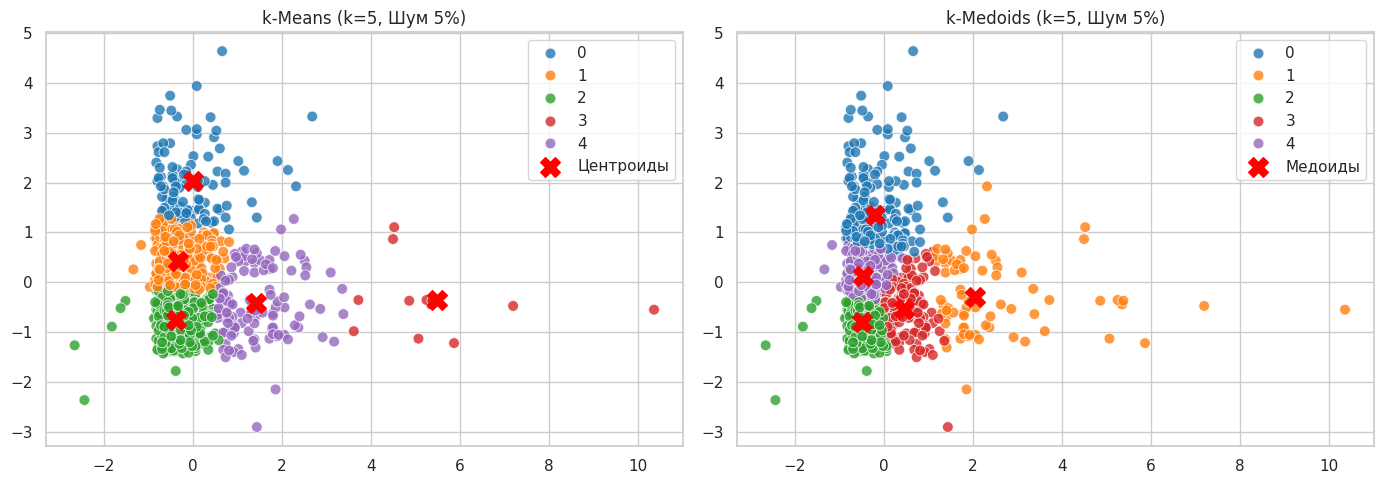

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=noisy_x[:, 0], y=noisy_x[:, 1],
    hue=km_labels, palette="tab10", ax=axes[0], s=60, alpha=0.8
)
axes[0].scatter(
    km_centers[:, 0], km_centers[:, 1],
    c='red', marker='X', s=200, label='Центроиды'
)
axes[0].set_title(f"k-Means (k={k_param}, Шум {int(noise_param*100)}%)")
axes[0].legend()

sns.scatterplot(
    x=noisy_x[:, 0], y=noisy_x[:, 1],
    hue=kmed_labels, palette="tab10", ax=axes[1], s=60, alpha=0.8
)
axes[1].scatter(
    kmed_centers[:, 0], kmed_centers[:, 1],
    c='red', marker='X', s=200, label='Медоиды'
)
axes[1].set_title(f"k-Medoids (k={k_param}, Шум {int(noise_param*100)}%)")
axes[1].legend()

plt.tight_layout()
plt.show()

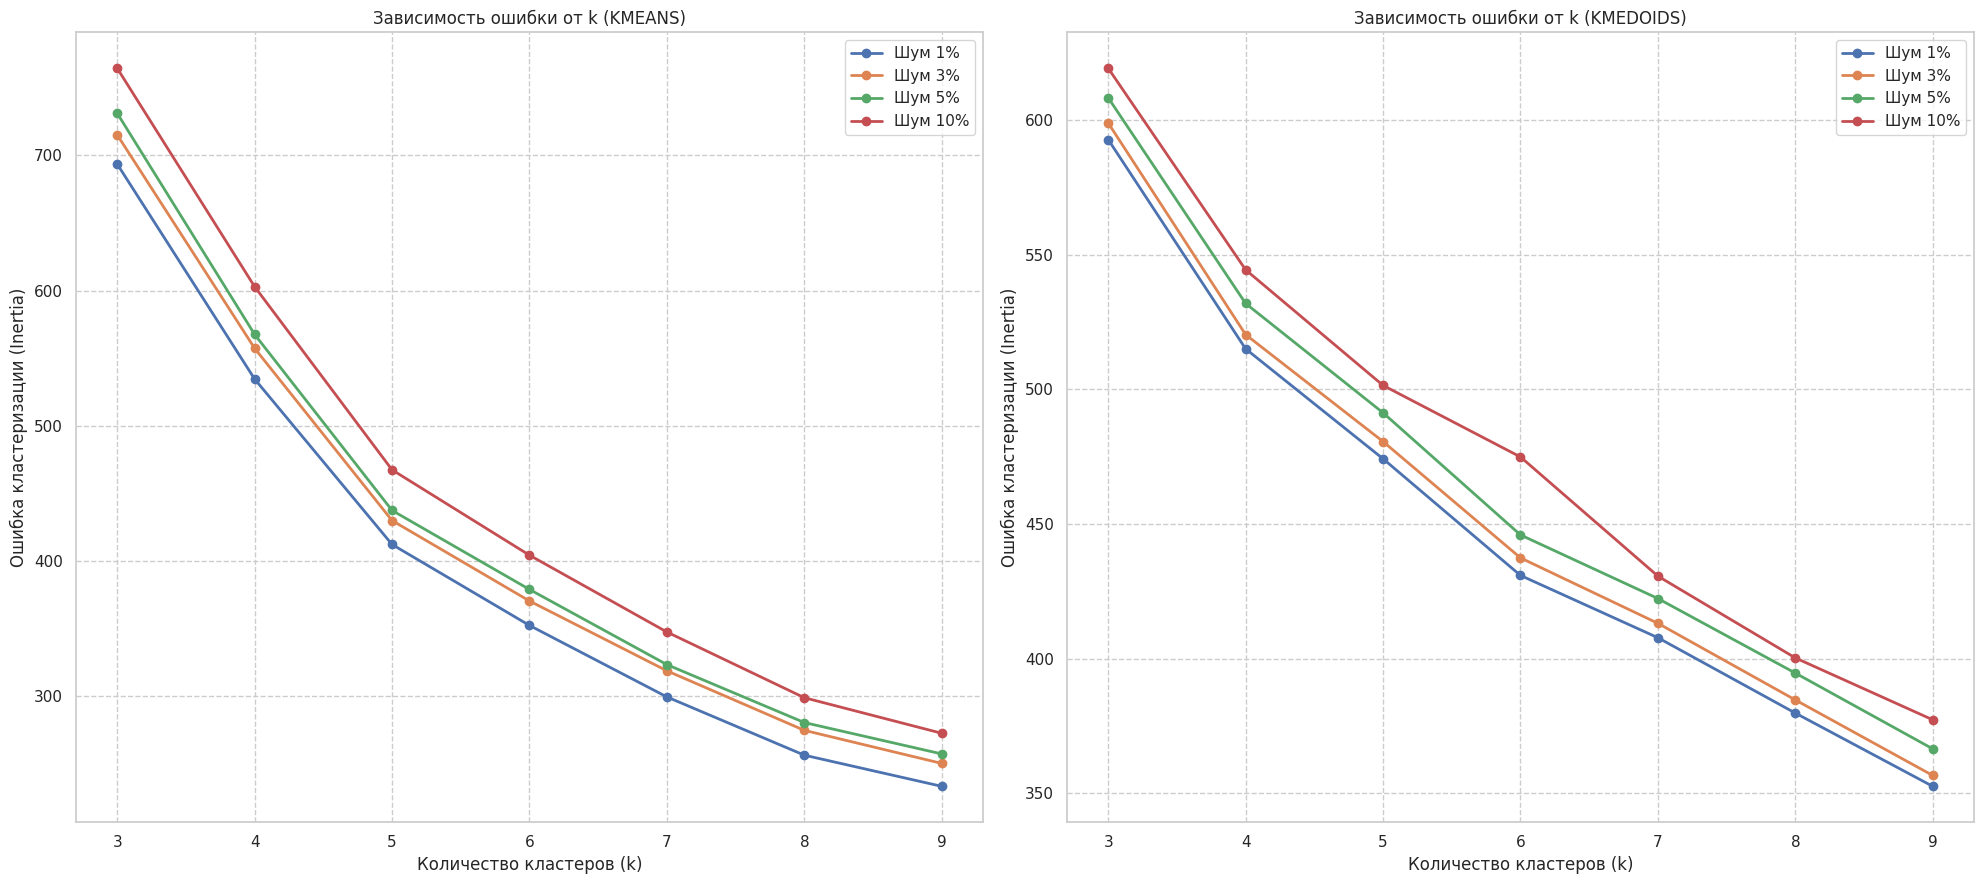

In [ ]:
noise_levels = [0.01, 0.03, 0.05, 0.10] # 1%, 3%, 5%, 10%
k_values = list(range(3, 10))
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for algo_idx, algo_name in enumerate(['kmeans', 'kmedoids']):
    for noise in noise_levels:
        data_with_noise = add_noise(scaled_data, noise_ratio=noise)
        errors = []

        for k in k_values:
            _, _, err = run_clustering(data_with_noise, algo_name, k)
            errors.append(err)

        axes[algo_idx].plot(
            k_values, errors,
            marker='o', linewidth=2,
            label=f'Шум {int(noise*100)}%'
        )

    axes[algo_idx].set_title(f"Зависимость ошибки от k ({algo_name.upper()})")
    axes[algo_idx].set_xlabel("Количество кластеров (k)")
    axes[algo_idx].set_ylabel("Ошибка кластеризации (Inertia)")
    axes[algo_idx].set_xticks(k_values)
    axes[algo_idx].legend()
    axes[algo_idx].grid(True, linestyle='--')

plt.tight_layout()
plt.show()